1. K-Means Clustering (Students Marks)

   Maths  Science  Cluster
0     35       30        0
1     40       35        0
2     45       40        0
3     80       78        1
4     85       82        1
5     90       88        1
6     60       55        0
7     65       60        0


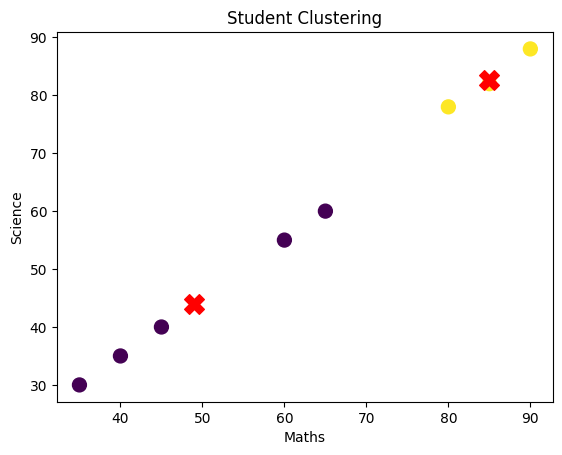

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = {
    "Maths":[35,40,45,80,85,90,60,65],
    "Science":[30,35,40,78,82,88,55,60]
}

df = pd.DataFrame(data)

model = KMeans(n_clusters=2, random_state=42)

df["Cluster"] = model.fit_predict(df)

print(df)

plt.scatter(df["Maths"], df["Science"], c=df["Cluster"], s=100)
plt.scatter(model.cluster_centers_[:,0],
            model.cluster_centers_[:,1],
            color="red",
            marker="X",
            s=200)

plt.xlabel("Maths")
plt.ylabel("Science")
plt.title("Student Clustering")
plt.show()

2. DBSCAN Clustering

[ 0  0  0  1  1 -1]


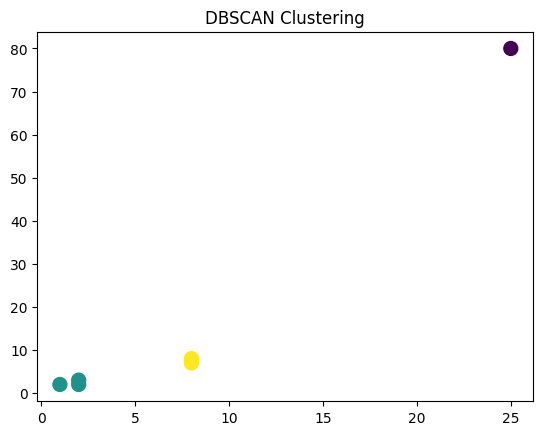

In [2]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

X = np.array([
    [1,2],[2,2],[2,3],
    [8,7],[8,8],[25,80]
])

db = DBSCAN(eps=2, min_samples=2)

labels = db.fit_predict(X)

print(labels)

plt.scatter(X[:,0], X[:,1], c=labels, s=100)
plt.title("DBSCAN Clustering")
plt.show()

3. Hierarchical Clustering

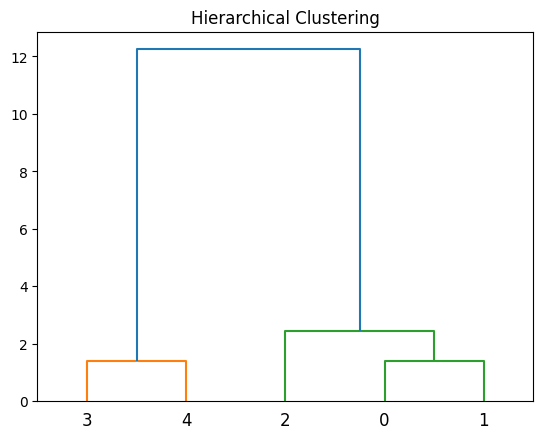

In [3]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

X = np.array([
    [1,2],
    [2,3],
    [3,4],
    [8,7],
    [9,8]
])

linked = linkage(X, method='ward')

dendrogram(linked)

plt.title("Hierarchical Clustering")
plt.show()

4. PCA

In [4]:
from sklearn.decomposition import PCA
import numpy as np

X = np.array([
    [2,3,4],
    [3,4,5],
    [5,6,7],
    [6,7,8]
])

pca = PCA(n_components=2)

result = pca.fit_transform(X)

print(result)

[[-3.46410162e+00 -3.43990023e-16]
 [-1.73205081e+00  1.14663341e-16]
 [ 1.73205081e+00 -1.14663341e-16]
 [ 3.46410162e+00 -2.29326682e-16]]


5. t-SNE

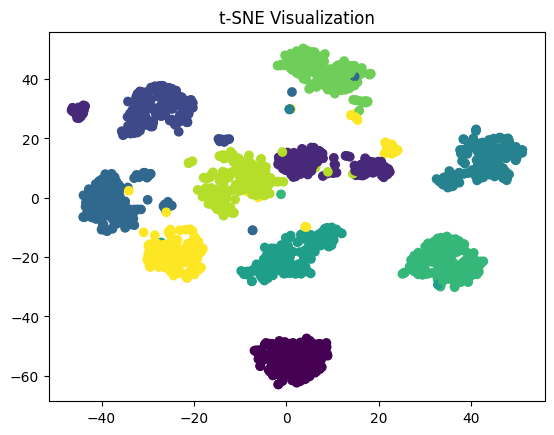

In [5]:
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()

tsne = TSNE(n_components=2, random_state=42)

X = tsne.fit_transform(digits.data)

plt.scatter(X[:,0], X[:,1], c=digits.target)

plt.title("t-SNE Visualization")
plt.show()

6. Market Basket Analysis (Apriori)

In [6]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

transactions = [
    ["Milk","Bread"],
    ["Milk","Butter"],
    ["Bread","Butter"],
    ["Milk","Bread","Butter"]
]

te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_array, columns=te.columns_)

frequent = apriori(df,
                   min_support=0.5,
                   use_colnames=True)

print(frequent)

   support         itemsets
0     0.75          (Bread)
1     0.75         (Butter)
2     0.75           (Milk)
3     0.50  (Bread, Butter)
4     0.50    (Bread, Milk)
5     0.50   (Milk, Butter)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


7. Association Rules

In [7]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent,
    metric="confidence",
    min_threshold=0.5
)

print(rules[['antecedents',
             'consequents',
             'support',
             'confidence',
             'lift']])

  antecedents consequents  support  confidence      lift
0     (Bread)    (Butter)      0.5    0.666667  0.888889
1    (Butter)     (Bread)      0.5    0.666667  0.888889
2     (Bread)      (Milk)      0.5    0.666667  0.888889
3      (Milk)     (Bread)      0.5    0.666667  0.888889
4      (Milk)    (Butter)      0.5    0.666667  0.888889
5    (Butter)      (Milk)      0.5    0.666667  0.888889


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

8. Customer Segmentation

In [8]:
import pandas as pd
from sklearn.cluster import KMeans

customers = pd.DataFrame({
    "Age":[20,22,25,45,48,50],
    "Income":[20000,22000,25000,60000,65000,70000]
})

model = KMeans(n_clusters=2, random_state=42)

customers["Group"] = model.fit_predict(customers)

print(customers)

   Age  Income  Group
0   20   20000      0
1   22   22000      0
2   25   25000      0
3   45   60000      1
4   48   65000      1
5   50   70000      1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

9. Iris Flower Clustering

In [9]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

iris = load_iris()

model = KMeans(n_clusters=3, random_state=42)

model.fit(iris.data)

print(model.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

10. Elbow Method

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

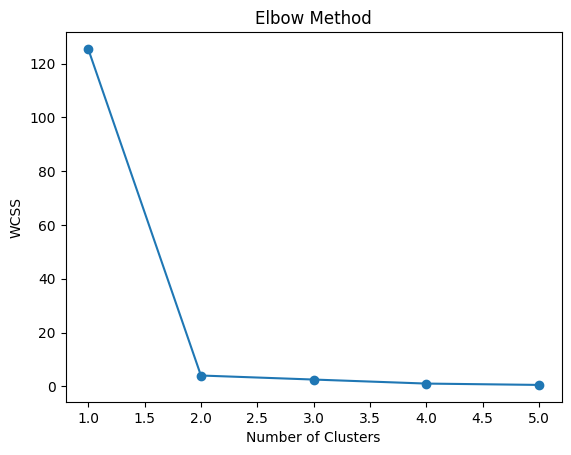

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = [[1],[2],[3],[10],[11],[12]]

wcss = []

for i in range(1,6):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(X)
    wcss.append(model.inertia_)

plt.plot(range(1,6), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()